# **COMPARACIÓN DE EMBEDDINGS EN TAREAS DE LENGUAJE NATURAL - ANÁLISIS DE SENTIMIENTOS EN TWEETS**

El objetivo de este cuadernillo es comparar el uso de distintos tipos de embeddings estáticos (TF-IDF, Word2Vec, GloVe, fastText) y contextuales (BERT) en el análisis de sentimientos de un dataset compuesto de muchos tweets. Los tweets se caracterizan por ser textos cortos y tener un lenguaje coloquial y lleno de abreviaturas.

Antes de entrar en la programación, recordamos la definición de *embedding*: Un embedding es una representación vectorial densa y continua de un objeto discreto (por ejemplo, una palabra, una oración) en un espacio de baja dimensión, donde las relaciones geométricas entre vectores capturan propiedades semánticas o estructurales.

Con esta definición, la representación vectorial TF-IDF quedaría fuera, ya que es una representación *sparse*, sin embargo, he decidido incluirla en la comparación por los buenos resultados que ofrece, especialmente para textos cortos como los tweets.

## **1. Cargar Datos**

### **1. 1. Cargar librerías de Python**

In [1]:
# Descargar librerías que no están en Google Collab por defecto
!pip install gensim
!pip install transformers datasets
!pip install wordcloud
!python -m spacy download es_core_news_sm
!pip install transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 24.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

In [3]:
# Utilidades
import time
import os
import random
from collections import Counter, defaultdict

In [4]:
# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [5]:
# Procesamiento del Lenguaje Natural (NLP)
import re
import spacy
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet = True)
nltk.download("punkt", quiet=True)

True

In [6]:
# Machine Learning (ML)

# Base
from sklearn.base import BaseEstimator, TransformerMixin

# Vectorización de texto
from sklearn.feature_extraction.text import TfidfVectorizer

# División de datos
from sklearn.model_selection import train_test_split, cross_val_score

# Modelos
from sklearn.linear_model import LogisticRegression

# Métricas y evaluación
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Pipelines
from sklearn.pipeline import Pipeline

# Embeddings
from gensim.models import Word2Vec, FastText

In [7]:
# BERT
import torch

# Tokenizador
from transformers import BertTokenizer

# BERT para clasificación
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
from transformers import EarlyStoppingCallback

### **1. 2. Cargar datos**

Los datos se pueden descargar en: https://www.kaggle.com/datasets/yasserh/twitter-tweets-sentiment-dataset. Aquí los cargo desde mi Drive.

In [8]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/TFG - Nolhan Denis Alonso Guignon/Análisis Sentimiento/Tweets.csv')
df.info()
df.head()

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


### **1. 3. Exploración inicial de los datos**

El objetivo es probar distintas representaciones vectoriales para los tokens y estudiar métricas como accuracy, F1 y tiempo de ejecución para determinar cual es el mejor embedding para esta tarea.

Por eso necesitamos evaluar todas las representaciones vectoriales bajo las mismas condiciones (o la más parecida que podamos). Queremos darle al modelo un texto y que devuelva una etiqueta de sentimiento, por lo que nos quedamos solo con las columnas 'text' y 'sentiment'.

Primero, investigamos la presencia de datos faltantes en nuestros datos.

In [9]:
df = df[['text', 'sentiment']]
df.isna().sum()

,0
text,1
sentiment,0


In [10]:
df[df['text'].isna()]

,text,sentiment
314,NaN,neutral


Solo hay un valor faltante en el texto, nos lo quitamos con dropna().

In [11]:
df = df.dropna()

Como la tarea es el análisis de sentimientos queremos saber cuántas categorías de sentimientos hay y cual es la proporción de los datos que cae en cada

In [12]:
counts = df['sentiment'].value_counts()
counts

,count
sentiment,
neutral,11117
positive,8582
negative,7781


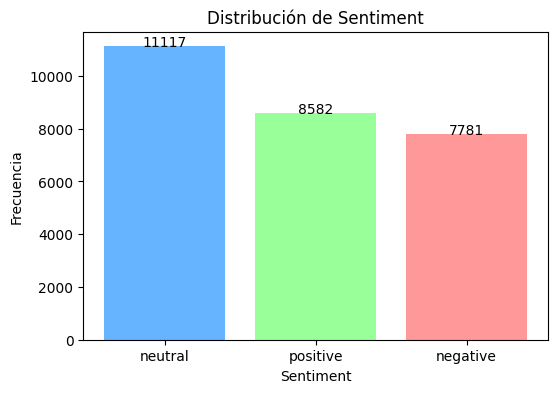

In [13]:
colors = ['#66B3FF', '#99FF99', '#FF9999']

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color=colors)

for i, value in enumerate(counts.values):
    plt.text(i, value + 0.2, str(value), ha='center')

plt.title('Distribución de Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Frecuencia')
plt.show()

Nos encontramos ante un problema de clasificación multiclase con 3 categorías que se corresponden a los sentimientos: neutro, positivo y negativo. Además las clases están ligeramente desbalanceadas (40.5%, 31.2%, 28.3%), más adelante trataremos este problema adecuadamente.

Terminamos este análisis inicial mostrando las dimensiones finales del dataset.

In [14]:
df.shape

(27480, 2)

El dataset final cuenta con 27480 filas (observaciones) y dos columnas: la variable predictora, texto, y la objetivo, sentimiento.

## **2. Preparación del Texto**

### **2. 1. Preprocesado del texto**

En los tweets aparecen muchas contracciones que vamos a normalizar ya que *I'll* es equivalente a *I will*, en general la mayoría de estás expresiones las vamos a eliminar en el futuro ya que no aportan sentimiento, por eso es importante normalizarlas para que no pasen el filtro posterior. Hacemos lo mismo para los números.

In [15]:
CONTRACTIONS = {
    "i'm":    "i am",       "i'll":   "i will",    "i'd":    "i would",
    "i've":   "i have",     "you're": "you are",   "you'll": "you will",
    "you'd":  "you would",  "you've": "you have",  "he's":   "he is",
    "she's":  "she is",     "it's":   "it is",     "we're":  "we are",
    "we'll":  "we will",    "we'd":   "we would",  "we've":  "we have",
    "they're":"they are",   "they'll":"they will", "they'd": "they would",
    "they've":"they have",  "that's": "that is",   "that'll":"that will",
    "isn't":  "is not",     "aren't": "are not",   "wasn't": "was not",
    "weren't":"were not",   "hasn't": "has not",   "haven't":"have not",
    "hadn't": "had not",    "won't":  "will not",  "wouldn't":"would not",
    "don't":  "do not",     "doesn't":"does not",  "didn't": "did not",
    "can't":  "cannot",     "couldn't":"could not","shouldn't":"should not",
    "mustn't":"must not",   "let's":  "let us",    "there's":"there is",
    "here's": "here is",    "who's":  "who is",    "what's": "what is",
    "where's":"where is",   "when's": "when is",   "how's":  "how is",
    "i'ma":   "i am going to",
}

DIGIT_MAP = {
    "0": "zero",  "1": "one",   "2": "two",   "3": "three", "4": "four",
    "5": "five",  "6": "six",   "7": "seven", "8": "eight", "9": "nine",
}

def _numbers_to_words(text: str) -> str:
    """
    Convierte números enteros a palabras (ej. 42 → 'four two').
    """
    def replace_num(m):
        n = m.group()
        # para números grandes usamos la cadena dígito a dígito
        return " ".join(DIGIT_MAP.get(d, d) for d in n)
    return re.sub(r"\b\d+\b", replace_num, text)

def _expand_contractions(text: str) -> str:
    for contraction, expansion in CONTRACTIONS.items():
        text = re.sub(r"\b" + re.escape(contraction) + r"\b", expansion, text)
    return text

La función principal de preprocesado hace transformaciones habituales: paso a minúsculas, normalización de apóstrofes, eliminar enlaces, ...

In [16]:
def preprocess_text(text: str) -> str:
    """
    Transforma un tweet crudo en texto limpio (str).
    Pasos:
      1. Minúsculas
      2. Normalizar apóstrofes tipográficos
      3. Expandir contracciones
      4. Eliminar URLs
      5. Reemplazar texto censurado (**bleep**) a <profanity>
      6. Números a palabras
      7. Eliminar caracteres especiales (conservar letras, dígitos, !, ?, .)
      8. Normalizar espacios
    """
    text = text.lower()                                    # minúsculas
    text = text.replace("\u2019", "'").replace("`", "'")   # curvo a recto
    text = _expand_contractions(text)                      # expandir contracciones
    text = re.sub(r"http\S+|www\S+", " ", text)            # URLs
    text = re.sub(r"\*{2,}", " <profanity> ", text)         # texto censurado
    text = re.sub(r"#+(\w+)", r"\1", text)                 # hashtags a palabra
    text = re.sub(r"@\w+", " ", text)                      # menciones
    text = _numbers_to_words(text)                         # números a texto
    text = re.sub(r"[^a-z\s!?.<>]", " ", text)             # chars especiales
    text = re.sub(r"\s+", " ", text).strip()
    return text

### **2. 2. Tokenización**



Después eliminaremos *stopwords* que son palabras demasiado frecuentes del idioma inglés, además normalizamos expresiones extendidas típicas de twitter, ya que el modelo no distingue cool de coool de cooool.

In [17]:
BASE_STOPWORDS = set(stopwords.words("english"))
BASE_STOPWORDS.update({"go", "get"})

def normalize_tokens(tokens: list[str]) -> list[str]:
    """Reduce elongaciones: 'cooool' → 'cool', 'noooo' → 'noo'."""
    return [re.sub(r"(.)\1{2,}", r"\1\1", w) for w in tokens]

Cuando necesitemos usar el texto tokenizado usaremos tokenización palabra a palabra. Además, hacemos lematización que consiste en pasar de derivaciones de una palabra a su palabra raiz que concentra el significado (going -> go).

In [18]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def tokenize_corpus(corpus: list[str]) -> list[list[str]]:
    return [
        [
            token.lemma_.lower()
            for token in doc
            if token.is_alpha and not token.is_stop
        ]
        for doc in nlp.pipe(corpus, batch_size=512, n_process=-1)
    ]

A continuación, tenemos la función que continua con el *pipeline* que hemos creado. Elimina palabras muy comunes y muy raras y también las demasiadas comunes a todas las categorías.

In [19]:
def process_tokens(
    corpus_clean: list[str],
    labels=None,
    min_df_frac: float = 0.001,
    max_df_frac: float = 0.50,
    top_n: int = 150,
    min_classes: int = 3,
):
    """
    Tokeniza, normaliza y filtra TODO el dataset completo.

    Flujo:
    1. Tokenización + normalización
    2. Eliminación inicial de BASE_STOPWORDS
    3. Cálculo de palabras comunes entre clases
    4. Eliminación de common_words
    5. Filtrado por document frequency

    Parámetros
    ----------
    corpus_clean : list[str]
        Textos ya preprocesados.

    labels : list | None
        Etiquetas de clase.
        Si es None, no se calcularán common_words.

    min_df_frac : float
        Frecuencia mínima documental.

    max_df_frac : float
        Frecuencia máxima documental.

    top_n : int
        Top-N palabras más frecuentes por clase.

    min_classes : int
        Número mínimo de clases para considerar una palabra común.

    Devuelve
    --------
    filtered_tokens : list[list[str]]
    df_counts       : Counter
    extended_sw     : set
    common_words    : set
    """

    N = len(corpus_clean)

    min_df = max(1, int(min_df_frac * N))
    max_df = int(max_df_frac * N)


    # 1. Tokenización + normalización

    tokenized = tokenize_corpus(corpus_clean)

    tokenized = [
        normalize_tokens(doc)
        for doc in tokenized
    ]


    # 2. Eliminar primero BASE_STOPWORDS

    tokenized_no_base_sw = [
        [w for w in doc if w not in BASE_STOPWORDS]
        for doc in tokenized
    ]


    # 3. Document Frequency GLOBAL

    df_counts = Counter(
        word
        for doc in tokenized_no_base_sw
        for word in set(doc)
    )

    common_words = set()


    # 4. Detectar palabras comunes entre clases

    if labels is not None:

        class_freq: dict[str, Counter] = defaultdict(Counter)

        for tokens, label in zip(tokenized_no_base_sw, labels):
            class_freq[label].update(tokens)

        top_words_per_class = {
            lbl: {w for w, _ in freq.most_common(top_n)}
            for lbl, freq in class_freq.items()
        }

        word_class_count = Counter(
            w
            for words in top_words_per_class.values()
            for w in words
        )

        common_words = {
            w
            for w, cnt in word_class_count.items()
            if cnt >= min_classes
        }

        print(
            f"Palabras comunes eliminadas "
            f"(top {top_n}, ≥{min_classes} clases): "
            f"{len(common_words)}"
        )


    # 5. Stopwords extendidas

    extended_sw = BASE_STOPWORDS | common_words


    # 6. Filtrado final

    filtered_tokens = [
        [
            w for w in doc
            if w not in common_words
            and min_df <= df_counts[w] <= max_df
        ]
        for doc in tokenized_no_base_sw
    ]

    return filtered_tokens, df_counts, extended_sw, common_words

### **2. 3. Limpieza**

Eliminamos tweets que han quedado vacíos o con pocas palabras.

In [20]:
def short_tweet_report(
    tokenized_corpus: list[list[str]],
    max_words: int = 2,
) -> tuple[int, list[int]]:
    """
    Cuenta e identifica tweets con <= max_words tokens tras el preprocesado.

    Parámetros
    ----------
    tokenized_corpus : lista de listas de tokens
    max_words        : umbral (inclusive) para considerar un tweet "demasiado corto"

    Devuelve
    --------
    count   : número de tweets cortos
    indices : lista de índices
    """
    indices = [i for i, doc in enumerate(tokenized_corpus) if len(doc) <= max_words]
    count = len(indices)
    print(f"Tweets con ≤{max_words} palabras: {count} "
          f"({100 * count / len(tokenized_corpus):.1f} %)")
    for k in range(max_words + 1):
        n = sum(1 for doc in tokenized_corpus if len(doc) == k)
        print(f"  {k} palabras → {n} tweets")
    return count, indices

### **2. 4. Pipeline de procesado**

La siguiente función aplica por fases todo el proceso que hemos construido devolviéndonos los datos listos para usar, separados en train/test (80/20), en distintos formatos: dataset sin procesar, dataset procesado sin tokenizar, dataset procesado y tokenizado.

In [21]:
def build_datasets(
    df: pd.DataFrame,
    text_col: str = "text",
    label_col: str = "label",
    test_size: float = 0.2,
    random_state: int = 42,
    min_df_frac: float = 0.001,
    max_df_frac: float = 0.80,
    top_n: int = 150,
    min_classes: int = 3,
    min_words: int = 2,
) -> dict:
    """
    Flujo:
    1. Preprocesado global
    2. Tokenización + filtrado global
    3. Eliminación global de textos cortos
    4. Split final consistente

    Esto garantiza:
    - mismo filtrado para todos los modelos
    - mismas observaciones en train/test
    - comparabilidad total entre experimentos
    """


    # 1. EXTRAER DATOS CRUDOS

    raw_all = df[text_col].tolist()
    y_all = df[label_col].tolist()


    # 2. PREPROCESADO GLOBAL

    print("Preprocesando texto globalmente …")

    clean_all = [
        preprocess_text(t)
        for t in raw_all
    ]


    # 3. TOKENIZACIÓN + FILTRADO GLOBAL

    print("Tokenizando y filtrando vocabulario global …")

    tok_all, df_counts, extended_sw, common_words = process_tokens(
        clean_all,
        labels=y_all,
        min_df_frac=min_df_frac,
        max_df_frac=max_df_frac,
        top_n=top_n,
        min_classes=min_classes,
    )

    removed_stopwords = set(BASE_STOPWORDS)
    removed_common = set(common_words)

    print("\n── FILTROS DE VOCABULARIO ──")
    print(f"Base stopwords: {len(removed_stopwords)}")
    print(f"Common words: {len(removed_common)}")
    print(f"Total stopwords extendidas: {len(extended_sw)}")

    # 4. DETECTAR TEXTOS CORTOS

    print("\n── Informe tweets cortos (global) ──")

    _, short_idx = short_tweet_report(
        tok_all,
        max_words=min_words
    )


    # 5. ELIMINAR TEXTOS CORTOS GLOBALMENTE

    def drop_indices(lst, bad_idx):
        bad = set(bad_idx)
        return [
            x for i, x in enumerate(lst)
            if i not in bad
        ]

    raw_all_f = drop_indices(raw_all, short_idx)
    clean_all_f = drop_indices(clean_all, short_idx)
    tok_all_f = drop_indices(tok_all, short_idx)
    y_all_f = drop_indices(y_all, short_idx)

    print(f"\n── SHORT TWEETS ──")
    print(f"Observaciones eliminadas: {len(short_idx)} ({len(short_idx)/len(tok_all):.2%})")
    print(f"\nTamaño final tras filtrado: {len(raw_all_f)}")

    vocab_final = set(
        w
        for doc in tok_all_f
        for w in doc
    )

    print(f"\n── VOCABULARIO FINAL ──")
    print(f"Tamaño vocabulario final: {len(vocab_final)}")
    print(f"Ejemplo palabras: {list(vocab_final)[:20]}")


    class_dist = Counter(y_all_f)

    print("\n── DISTRIBUCIÓN POR CLASE (ANTES DEL SPLIT) ──")
    for k, v in class_dist.items():
        print(f"{k}: {v} ({v/len(y_all_f):.2%})")

    # 6. SPLIT FINAL

    idx_final = list(range(len(raw_all_f)))

    idx_train, idx_test = train_test_split(
        idx_final,
        test_size=test_size,
        random_state=random_state,
        stratify=y_all_f,
    )

    def split_by_idx(lst):
        train = [lst[i] for i in idx_train]
        test = [lst[i] for i in idx_test]
        return train, test

    # RAW
    raw_train, raw_test = split_by_idx(raw_all_f)

    # CLEAN
    clean_train, clean_test = split_by_idx(clean_all_f)

    # TOKENIZED
    tok_train, tok_test = split_by_idx(tok_all_f)

    # LABELS
    y_train, y_test = split_by_idx(y_all_f)

    print(
        f"\nSplit final -> "
        f"train: {len(raw_train)} | "
        f"test: {len(raw_test)}"
    )

    # 7. RETURN

    return {
        "raw": (
            raw_train,
            raw_test,
            y_train,
            y_test,
        ),

        "clean": (
            clean_train,
            clean_test,
            y_train,
            y_test,
        ),

        "tokenized": (
            tok_train,
            tok_test,
            y_train,
            y_test,
        ),

        "meta": {
            "df_counts": df_counts,
            "extended_sw": extended_sw,
            "common_words": common_words,
            "short_idx_global": short_idx,
            "idx_train": idx_train,
            "idx_test": idx_test,
        },
    }

In [22]:
datasets = build_datasets(
        df,
        text_col="text",
        label_col="sentiment",
        test_size=0.20,
        random_state=42,
        min_df_frac=0.001,               # Afecta fuertemente a la clasificación de palabras negativas, aumentarlo reduce drásticamente el vocabulario y los tweets del dataset. No recomiendo subirlo por encima de 0.001.
        max_df_frac=0.1,                 # Empeora la clasificación de positivo.
        top_n=0,                         # En 0 desactiva la eliminación de palabras comunes por categorías. No da buenos resultados incluso para tops pequeños, es mejor no usarlo.
        min_classes=3,
        min_words=1,
    )

# ── Desempaquetar ────────────────────────────────────────────────────
X_train_raw,   X_test_raw,   y_train, y_test = datasets["raw"]
X_train_clean, X_test_clean, _,       _      = datasets["clean"]
X_train_tok,   X_test_tok,   _,       _      = datasets["tokenized"]

# Versión "texto limpio unido" (para TF-IDF)
X_train_str = [" ".join(doc) for doc in X_train_tok]
X_test_str  = [" ".join(doc) for doc in X_test_tok]

# ── Acceder a metadatos ──────────────────────────────────────────────
meta = datasets["meta"]

Preprocesando texto globalmente …
Tokenizando y filtrando vocabulario global …
Palabras comunes eliminadas (top 0, ≥3 clases): 0

── FILTROS DE VOCABULARIO ──
Base stopwords: 200
Common words: 0
Total stopwords extendidas: 200

── Informe tweets cortos (global) ──
Tweets con ≤1 palabras: 4121 (15.0 %)
  0 palabras → 977 tweets
  1 palabras → 3144 tweets

── SHORT TWEETS ──
Observaciones eliminadas: 4121 (15.00%)

Tamaño final tras filtrado: 23359

── VOCABULARIO FINAL ──
Tamaño vocabulario final: 867
Ejemplo palabras: ['blue', 'present', 'gift', 'happen', 'em', 'shower', 'l', 'hi', 'london', 'expect', 'bored', 'twitter', 'hand', 'light', 'state', 'service', 'life', 'parent', 'church', 'need']

── DISTRIBUCIÓN POR CLASE (ANTES DEL SPLIT) ──
negative: 6838 (29.27%)
positive: 7828 (33.51%)
neutral: 8693 (37.21%)

Split final -> train: 18687 | test: 4672


In [23]:
common_words = meta["common_words"]
common_words

set()

In [36]:
n = len(X_train_raw)

sample_idx = random.sample(range(n), 10)

rows = []

for i in sample_idx:
    rows.append({
        "idx": i,
        "raw": X_train_raw[i],
        "clean": X_train_clean[i],
        "tokenized": " ".join(X_train_tok[i]),
        "label": y_train[i]
    })

df_sample = pd.DataFrame(rows)

df_sample

,idx,raw,clean,tokenized,label
0,7603,"So far absolutely perfect. Great view, directl...",so far absolutely perfect. great view directly...,far absolutely perfect great ice machine weath...,positive
1,14329,"I don`t know what that means, sorry",i do not know what that means sorry,know mean sorry,negative
2,15946,"had an amazingly unproductive day, but i loved...",had an amazingly unproductive day but i loved ...,day love time catch sleep,positive
3,8495,I have a stomach ache... Totally sucks,i have a stomach ache... totally sucks,stomach totally suck,negative
4,7709,http://twitpic.com/4wij6 - my oldest nephew pl...,my oldest nephew playin on my guitar hero drums,old guitar,neutral
5,2472,heylo johnn (: im a huge fan. hope ur day is ...,heylo johnn im a huge fan. hope ur day is awes...,huge fan hope ur day home sick kinda awesome,neutral
6,6424,"$900 cheque to cash tomorrow, why I didn`t get...",nine zero zero cheque to cash tomorrow why i d...,zero zero tomorrow bank idea feel safe woo,positive
7,11988,Thank you for approving my application at the...,thank you for approving my application at the ...,thank good work,positive
8,14446,Starting my 2nd shift! Im going to miss like a...,starting my nd shift! im going to miss like an...,start nd shift miss like hour game,negative
9,17734,aww cant wait to have you back in LA! <333,aww cant wait to have you back in la! <three t...,aww wait la,positive


### **2. 5. WordClouds**

Una forma de visualizar que está eliminando y manteniendo nuestro preprocesado es a través de los gráficos de nubes de palabras.

In [47]:
PALETTE = {
    "positive": {"bg": "#6fbf73", "text": "#1b5a35"},
    "neutral":  {"bg": "#5f86c2", "text": "#1a2f4f"},
    "negative": {"bg": "#d96a6a", "text": "#5a1414"},
}

def make_color_func(color):
    def color_func(*args, **kwargs):
        return color
    return color_func

def plot_wordclouds_by_label(
    tokenized_corpus,
    labels,
    figsize=(18, 5),
    max_words=120,
):
    unique_labels = sorted(set(labels))
    fig, axes = plt.subplots(1, len(unique_labels), figsize=figsize)

    for ax, label in zip(axes, unique_labels):

        palette = PALETTE.get(label, {"bg": "#ffffff", "text": "#000000"})
        bg = palette["bg"]
        text_color = palette["text"]

        tokens = [
            w for doc, lbl in zip(tokenized_corpus, labels)
            if lbl == label
            for w in doc
        ]

        freq = Counter(tokens)

        wc = WordCloud(
            width=700,
            height=400,
            background_color=bg,
            max_words=max_words,
            colormap=None,  # ❌ MUY IMPORTANTE
            color_func=make_color_func(text_color),  # ✔ control total
            collocations=False,
            prefer_horizontal=0.9,
        ).generate_from_frequencies(freq)

        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(
            label.capitalize(),
            fontsize=14,
            fontweight="bold",
            color=text_color,
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

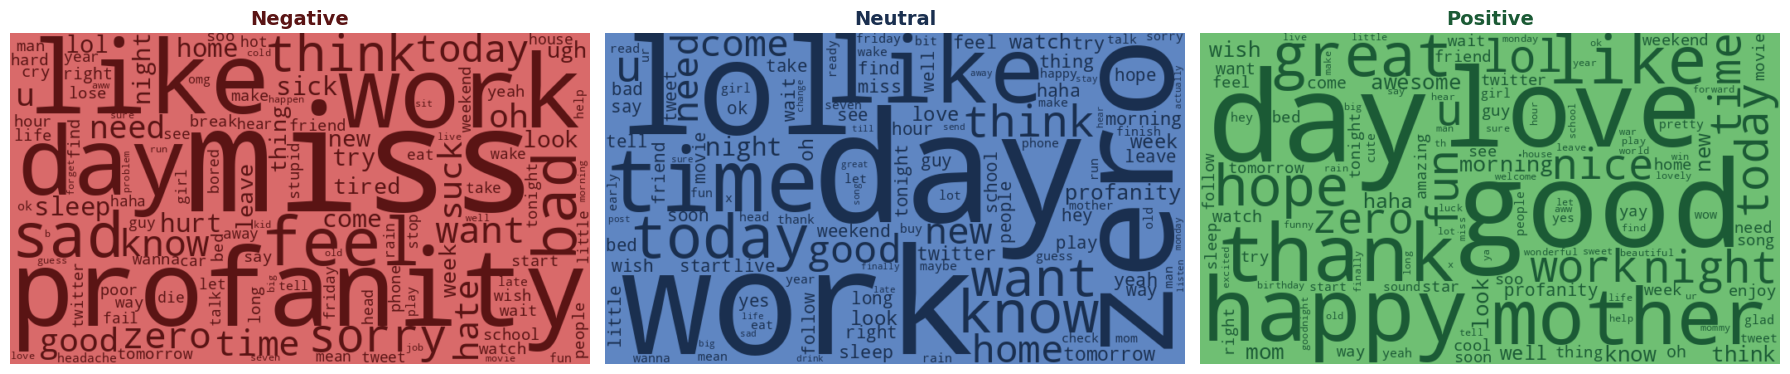

In [46]:
plot_wordclouds_by_label(X_train_tok, y_train)

### **2.6. Distribución de palabras más comunes**

Vamos a comparar la distribución de las 20 palabras más comunes antes (clean) y después del preprocesado (token).

In [48]:
def tokenize(text):
    return text.lower().split()

tokens_before = [w for text in X_train_clean for w in tokenize(text)]
tokens_after = [w for doc in X_train_tok for w in doc]

In [49]:
top_before = Counter(tokens_before).most_common(20)
top_after = Counter(tokens_after).most_common(20)

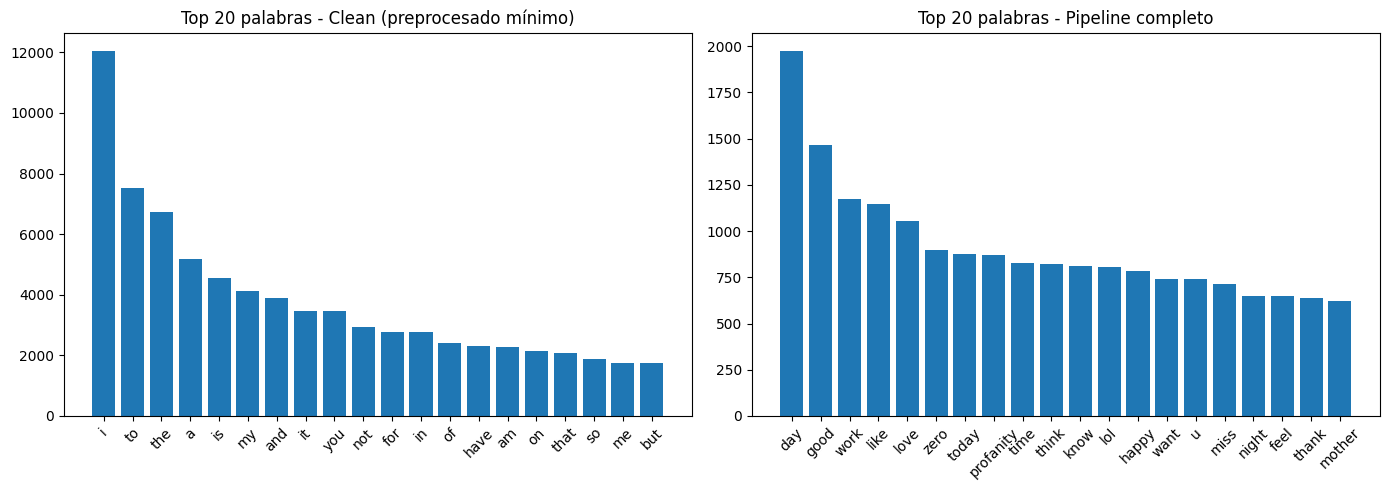

In [50]:
words_b, counts_b = zip(*top_before)
words_a, counts_a = zip(*top_after)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(words_b, counts_b)
axes[0].set_title("Top 20 palabras - Clean (preprocesado mínimo)")
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(words_a, counts_a)
axes[1].set_title("Top 20 palabras - Pipeline completo")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## **3. Embeddings Estáticos**


### **3.1. TF-IDF**

El método TF-IDF (Term Frequency-Inverse Document Frequency) es una de las técnicas de representación vectorial (embedding) más básicas. Consiste en dos términos por token y documento:

$$TF(t, d) = \frac{f(t, d)}{|d|}$$

- $f(t, d)$: número de veces que aparece el término t en el documento d
- $|d|$: número total de palabras en el documento

$$IDF(t) = \log\left(\frac{N}{df(t)}\right)$$

- $N$: número total de documentos
- $df(t)$: número de documentos que contienen el término t

$$TF\text{-}IDF(t, d) = TF(t, d) \cdot IDF(t)$$

De esta forma se consigue ponderar a cada palabra en su contexto penalizando fuertemente palabras como preposiciones o determinantes que son poco informativas y aparecen muchas veces.

Existe una función que hace esta tarea en la biblioteca sklearn (https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html).

La función viene con algunos ajustes por defecto como el uso de la codificación utf-8 y algunas otros procesos de preprocesamiento para normalizar el texto. Si queremos podemos limitar el tamaño del vocabulario, por ejemplo, si queremos ahorrar memoria, esto se hace con max_features. También podemos seleccionar los n-gramas a considerar que es un hiperparámetro, esto se hace mediante ngram_range. Con el argumento stop_words podemos eliminar palabras muy habituales de un idioma y que no aportan información, por ejemplo "the", aunque en nuestro caso ya las hemos eliminado antes.

In [51]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
)

Aplicamos el embedding a los datos de entrenamiento, al usar fit_transform estamos aprendiendo el vocabulario del dataset (fit) y después convertiendo el texto a vectores (transform). Podemos ver la dimensión de los datos. Se trata de una matriz enorme y muy dispersa en la que casi todos los elementos son ceros. En la práctica esto es poco deseable ya que requiere mucha memoria.

In [52]:
X_train_vec = vectorizer.fit_transform(X_train_str)
print(X_train_vec.shape)

(18687, 5000)


A los datos de entrenamiento solo aplicamos transform porque no queremos que aprenda nuevas palabras.

In [53]:
X_test_vec = vectorizer.transform(X_test_str)
print(X_test_vec.shape)

(4672, 5000)


In [54]:
model = LogisticRegression(max_iter = 1000)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)
print(classification_report(y_test, y_pred)) # Hemos mejorado positivo y negativo pero empeorado neutral

              precision    recall  f1-score   support

    negative       0.71      0.63      0.67      1367
     neutral       0.62      0.68      0.65      1739
    positive       0.76      0.75      0.76      1566

    accuracy                           0.69      4672
   macro avg       0.70      0.69      0.69      4672
weighted avg       0.69      0.69      0.69      4672



Queremos estudiar la eficacia del modelo para distintos hiperparámetros, para esto vamos a ejecutar en bucle el pipeline anterior guardándonos en cada caso el tipo de ngrams usados, el accuracy, el f1-score y el tiempo de ejecución.

In [55]:
n_gram_max = 6
results = []

for i in range(1, n_gram_max + 1):
    start = time.time()

    vectorizer = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, i),
    )

    X_train_vec = vectorizer.fit_transform(X_train_str)
    X_test_vec = vectorizer.transform(X_test_str)

    model = LogisticRegression(max_iter = 3000) # Importante: Reiniciar el modelo dentro del bucle.
    model.fit(X_train_vec, y_train)

    y_pred = model.predict(X_test_vec)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    end = time.time()
    duracion = end - start

    results.append((i, accuracy, f1, duracion))

    print(f"N-gramas: {i} | Accuracy: {accuracy:.4f} | F1: {f1:.4f} | Tiempo: {duracion:.2f}s")

N-gramas: 1 | Accuracy: 0.6948 | F1: 0.6956 | Tiempo: 0.39s
N-gramas: 2 | Accuracy: 0.6886 | F1: 0.6893 | Tiempo: 2.59s
N-gramas: 3 | Accuracy: 0.6879 | F1: 0.6886 | Tiempo: 5.73s
N-gramas: 4 | Accuracy: 0.6888 | F1: 0.6894 | Tiempo: 2.81s
N-gramas: 5 | Accuracy: 0.6892 | F1: 0.6899 | Tiempo: 2.50s
N-gramas: 6 | Accuracy: 0.6890 | F1: 0.6897 | Tiempo: 3.27s


El modelo que considera unigramas es el que ofrece mejores resultados, en gran parte porque hemos eliminado muchas palabras en el preprocesado y hemos perdido expresiones tipo "very good" o "not good" y palabras que tienen distintas connotaciones según el contexto.

A partir de aquí vamos a realizar los análisis haciendo validación cruzada en todos los modelos, en particular, haremos un 5-fold sobre el conjunto train.

In [26]:
CV_FOLDS = 5

Vamos a definir una función general que nos permita aplicar la misma metodología para todos los embeddings, aquí tenemos que gestionar adecuadamente los tipos de objetos con los que trabajamos.

In [57]:
def evaluate(model, X_train_vec, X_test_vec, y_train, y_test, label, cv_scores=None):
    """Entrena, predice y muestra métricas. cv_scores se pasa ya calculado."""
    clf = LogisticRegression(max_iter=10000)
    clf.fit(X_train_vec, y_train)
    y_pred = clf.predict(X_test_vec)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')

    if cv_scores is not None:
        cv_mean, cv_std = cv_scores.mean(), cv_scores.std()
        print(f"{label} | F1 CV: {cv_mean:.4f} ± {cv_std:.4f} | "
              f"Accuracy test: {acc:.4f} | F1 test: {f1:.4f}")
    else:
        print(f"{label} | Accuracy test: {acc:.4f} | F1 test: {f1:.4f}")

    return clf

También necesitamos una función que nos transforme los embeddings de cada palabra en un solo vector por documento que es el que le pasamos al clasificador.

In [58]:
def tokens_to_mean_vec(token_lists, wv_model, dim):
    """
    Promedia los embeddings de las palabras de cada documento.
    """
    def doc_vec(tokens):
        vecs = [wv_model[w] for w in tokens if w in wv_model]
        return np.mean(vecs, axis=0) if vecs else np.zeros(dim)
    return np.array([doc_vec(tok) for tok in token_lists])

Iremos usando estas funciones en todos los embeddings. Primero las aplicamos a TF-IDF

In [60]:
for n in range(1, 7):
    start = time.time()

    # Pipeline completo: vectorización + clasificador, necesario para CV
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, n))),
        ("clf",   LogisticRegression(max_iter=10000)),
    ])

    # Validación cruzada sobre train con F1 weighted
    cv_scores = cross_val_score(
        pipe,
        X_train_str,
        y_train,
        cv=CV_FOLDS,
        scoring="f1_weighted"
    )

    # Ajuste final sobre todo el train
    pipe.fit(X_train_str, y_train)

    # Predicciones
    y_pred_train = pipe.predict(X_train_str)
    y_pred_test  = pipe.predict(X_test_str)

    # Métricas
    f1_train = f1_score(y_train, y_pred_train, average='weighted')
    acc_test = accuracy_score(y_test, y_pred_test)
    f1_test  = f1_score(y_test, y_pred_test, average='weighted')

    elapsed = time.time() - start

    print(
        f"N-gramas: {n} | "
        f"F1 CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | "
        f"F1 train: {f1_train:.4f} | "
        f"Accuracy test: {acc_test:.4f} | "
        f"F1 test: {f1_test:.4f} | "
        f"Tiempo: {elapsed:.2f}s"
    )

N-gramas: 1 | F1 CV: 0.6836 ± 0.0050 | F1 train: 0.7243 | Accuracy test: 0.6948 | F1 test: 0.6956 | Tiempo: 7.41s
N-gramas: 2 | F1 CV: 0.6811 ± 0.0031 | F1 train: 0.8598 | Accuracy test: 0.6896 | F1 test: 0.6894 | Tiempo: 65.69s
N-gramas: 3 | F1 CV: 0.6805 ± 0.0049 | F1 train: 0.8890 | Accuracy test: 0.6866 | F1 test: 0.6864 | Tiempo: 79.28s
N-gramas: 4 | F1 CV: 0.6800 ± 0.0057 | F1 train: 0.9021 | Accuracy test: 0.6866 | F1 test: 0.6867 | Tiempo: 93.77s
N-gramas: 5 | F1 CV: 0.6788 ± 0.0061 | F1 train: 0.9068 | Accuracy test: 0.6856 | F1 test: 0.6859 | Tiempo: 69.12s
N-gramas: 6 | F1 CV: 0.6780 ± 0.0064 | F1 train: 0.9097 | Accuracy test: 0.6851 | F1 test: 0.6855 | Tiempo: 59.45s


A pesar de que el modelo de unigramas es el que mejor funciona al evaluarlo en test, ofrece resultados ligeramente peores en la validación cruzada. Aun así, las diferencias que se dan entre el f1-score de la validación cruzada de los distintos modelos de n-gramas que hemos considerado son mínimas y estadísticamente muy similares.

Aunque hemos considerado el modelo con hexagramas esto no tiene demasiado sentido en los tweets ya que son textos cortos, y con todo el preprocesado que hemos aplicado debe haber pocos hexagramas que el modelo pueda considerar. Esto puedo explicar el empeoramiento del modelo en test al aumentar el número de n-gramas.

Esta misma lógica se aplica similarmente a 5-gramas, 4-gramas, ... y es que según hemos aumentado la complejidad del modelo han ido apareciendo las sintomatologías típicas del sobreajuste.

Algunas consideraciones necesarias sobre las métricas que estamos utilizando:

- El *accuracy* mide la cantidad de clasificaciones correctas.

- El *F1-score* combina *precision* ($\frac{TP}{TP + FP}$) y *recall* ($\frac{TP}{TP + FN}$) resultando en una medida más adecuada para cuando los datos están desbalanceados.

En nuestro caso, como hemos hecho la separación train/test de forma estratificada no tenemos problemas graves de desbalanceo de clases (en test). Y, por tanto, los resultados por ambas métricas son similares. Podemos seguir cualquiera de los dos como criterio, eso sí, no podemos comparar el valor del *accuracy* con el *F1-score* directamente.

### **3. 2. Word2Vec**

La representación mediante TF-IDF, aunque efectiva como punto de partida, presenta el inconveniente de generar vectores de muy alta dimensión y naturaleza dispersa *sparse*, donde la mayoría de los valores son cero, lo que dificulta capturar relaciones semánticas entre palabras y puede afectar a la eficiencia computacional.

Para abordar estas limitaciones, vamos a ver distintos modelos de word embeddings como Word2Vec, que se basan en redes neuronales poco profundas para aprender representaciones vectoriales densas de las palabras a partir de su contexto en el corpus, de modo que términos con significado similar presentan vectores cercanos en el espacio vectorial.


La biblioteca gensim cuenta con una implementación de Word2Vec (https://tedboy.github.io/nlps/_modules/gensim/models/word2vec.html#Word2Vec) que cuenta con distintos argumentos:

- sentences: Texto tokenizado.

- vector_size: Hiperparámetro en el que elegimos la dimensión de nuestros vectores (normalmente entre 100 y 300).

- window: Establece el tamaño de la ventana de contexto considerada alrededor de cada palabra.
  
- min_count: Fija la frecuencia mínima para incluir una palabra en el vocabulario.
   
- workers: Determina el número de hilos utilizados para paralelizar el entrenamiento.
   
- sg: Permite seleccionar el algoritmo de aprendizaje, siendo 0 para Continuous Bag of Words y 1 para Skip-gram.

Ya que la función nos lo permite vamos a comparar las métricas de interés para Word2Vec usando CBOW y usando Skip-gram.

#### **CBOW**

Continuous Bag of Words se basa en predecir una palabra a partir de su contexto, fijando un tamaño de ventana. Es decir, a partir de una ventana se pretende inferir la palabra central, de esta forma se capturan estructuras regulares del lenguaje. Esta aproximación promedia la información del contexto lo cual hace que sea computacionalmente eficiente sobre todo para textos grandes. Sin embargo, al hacer promedios se pierde información relativa al orden de aparición de las palabras.

#### **Skip Gram**

El modelo Skip-gram invierte el enfoque de CBOW ya que trata de predecir el contexto a través de la palabra objetivo. Este planteamiento ayuda al modelo a aprender representaciones más precisas para cada palabra individual, esto es útil especialmente para las palabras poco frecuentes. Esta mayor finura y capacidad de captar relaciones semánticas se compensa con un mayor coste computacional, lo que hace que el modelo pueda no ser adecuado para corpus con estructuras muy reptitivas y pocas palabras raras.

In [30]:
class MeanEmbeddingTransformer(BaseEstimator, TransformerMixin):
    """
    Convierte listas de tokens en vectores promedio de embeddings.
    """

    def __init__(self, wv, dim):
        self.wv  = wv   # dict-like: palabra y np.array
        self.dim = dim

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        def doc_vec(tokens):
            vecs = [self.wv[w] for w in tokens if w in self.wv]
            return np.mean(vecs, axis=0) if vecs else np.zeros(self.dim)
        return np.array([doc_vec(tok) for tok in X])


In [62]:
W2V_DIM = 200

for sg, label in [(0, "CBOW"), (1, "Skip-gram")]:
    start = time.time()

    # Entrenamos Word2Vec solo con train
    w2v = Word2Vec(
        sentences=X_train_tok,
        vector_size=W2V_DIM,
        window=5,
        min_count=1,
        workers=10,
        sg=sg,
    )

    # Pipeline embedding y clasificador
    pipe = Pipeline([
        ("emb", MeanEmbeddingTransformer(w2v.wv, W2V_DIM)),
        ("clf", LogisticRegression(max_iter=10000)),
    ])

    # CV en train
    cv_scores = cross_val_score(
        pipe,
        X_train_tok,
        y_train,
        cv=CV_FOLDS,
        scoring="f1_weighted"
    )

    # Fit final en train completo
    pipe.fit(X_train_tok, y_train)

    # Predicciones
    y_pred_train = pipe.predict(X_train_tok)
    y_pred_test  = pipe.predict(X_test_tok)

    # Métricas
    f1_train = f1_score(y_train, y_pred_train, average='weighted')
    acc_test = accuracy_score(y_test, y_pred_test)
    f1_test  = f1_score(y_test, y_pred_test, average='weighted')

    elapsed = time.time() - start

    print(
        f"Word2Vec {label} | "
        f"F1 CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | "
        f"F1 train: {f1_train:.4f} | "
        f"Accuracy test: {acc_test:.4f} | "
        f"F1 test: {f1_test:.4f} | "
        f"Tiempo: {elapsed:.2f}s"
    )


Word2Vec CBOW | F1 CV: 0.5331 ± 0.0101 | F1 train: 0.5371 | Accuracy test: 0.5394 | F1 test: 0.5325 | Tiempo: 29.18s
Word2Vec Skip-gram | F1 CV: 0.5820 ± 0.0058 | F1 train: 0.5867 | Accuracy test: 0.5807 | F1 test: 0.5814 | Tiempo: 40.67s


Lo que estamos haciendo es entrenar el Word2Vec con todos los datos de train y después hacer validación cruzada en el clasificador, no es un problema de *data leakage* convencional, pero si se debe tener conocimiento de que parte del modelo ve todos los datos de entrenamiento y cual no.

Antes, con TF-IDF la validación cruzada la hacíamos sobre la construcción de los vectores y la clasificación.

Puede llamar la atención que los resultados con Word2Vec sean bastante peores que con TF-IDF, con métricas ligeramente superiores a 0.5 y mayor tiempo de ejecución.

Esto se explica porque Word2Vec trabaja a nivel de palabra y, al promediar los embeddings para representar cada tweet, se pierde información importante como el orden o las negaciones. Además, todas las palabras contribuyen por igual, a diferencia de TF-IDF, que destaca las más relevantes.

El resultado de Skip-gram es notablemente mejor, a pesar de tardar un poco más, esto puede deberse a las características propias de los textos de twitter de miles de personas distintas de forma que no se obedecen estructuras formales como si puede ocurrir en textos científicos o literarios.

### **3. 4. GloVe (pretrained)**

GloVe (Global Vectors for Word Representation) es un enfoque que combina ideas de modelos de conteo de palabras y modelos predictivos como Word2Vec. Mientras Word2Vec aprende embeddings tratando de predecir palabras en contexto (CBOW o Skip-Gram), GloVe construye primero una matriz de coocurrencia global del corpus y luego factoriza esa matriz para obtener vectores que capturan relaciones semánticas a gran escala.

La ventaja principal es que GloVe tiende a reflejar mejor las relaciones semánticas globales, por ejemplo analogías tipo “rey - hombre + mujer $\approx$ reina”. En cambio, Word2Vec está más centrado en relaciones locales, de ventana de contexto, y puede no capturar patrones globales tan explícitamente. Por otro lado, GloVe pierde algo de flexibilidad en la actualización dinámica de embeddings: si el corpus cambia, hay que rehacer la matriz de coocurrencia, mientras Word2Vec puede seguir entrenando incrementalmente.

Para nuestra tarea de análisis de sentimiento en tweets, GloVe tiene cierta ventaja porque los embeddings preentrenados ya codifican relaciones semánticas generales de palabras, ayudando a capturar matices emocionales incluso en frases cortas y ruidosas. Esto puede mejorar la representación frente a Word2Vec entrenado solo con nuestro dataset limitado.

In [63]:
# !rm -f glove.6B.zip glove.6B.200d.txt

La documentación oficial de los modelos GloVe preentrenados se encuentra en la página del proyecto: https://nlp.stanford.edu/projects/glove/. Allí se pueden consultar detalles sobre los diferentes modelos disponibles, los tamaños de vocabulario, la dimensión de los embeddings y los corpus sobre los que fueron entrenados.

El modelo preentrenado que usamos tiene dimensión 200 y fue entrenado sobre Wikipedia 2014 + Gigaword 5, lo que le da un vocabulario de alrededor de 400.000 palabras. Cada palabra está representada como un vector de 200 dimensiones en punto flotante (float32). El archivo está en texto plano, con cada línea conteniendo la palabra seguida de los 200 valores del vector. Este modelo es adecuado para nuestro dataset de tweets porque contiene muchas palabras comunes en inglés y expresiones frecuentes en contextos generales, lo que facilita capturar el significado de los tweets sin necesidad de entrenar un modelo desde cero.

In [64]:
if not os.path.exists("glove.6B.200d.txt"):
    if not os.path.exists("glove.6B.zip") and not os.path.exists("glove.6B.zip.2"):
        print("Downloading glove.6B.zip...")
        !wget http://nlp.stanford.edu/data/glove.6B.zip

    zip_file_to_unzip = "glove.6B.zip"

    if not os.path.exists(zip_file_to_unzip) and os.path.exists("glove.6B.zip.2"):
        zip_file_to_unzip = "glove.6B.zip.2"

    print(f"Unzipping {zip_file_to_unzip}...")
    !unzip -o {zip_file_to_unzip} glove.6B.200d.txt

def load_glove(path):
    embeddings = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.array(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

glove = load_glove("glove.6B.200d.txt")

--2026-06-02 11:26:26--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-06-02 11:26:26--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-06-02 11:26:26--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [65]:
GLOVE_DIM = 200

start = time.time()

pipe_glove = Pipeline([
    ("emb", MeanEmbeddingTransformer(glove, GLOVE_DIM)),
    ("clf", LogisticRegression(max_iter=10000)),
])

# CV en train
cv_scores = cross_val_score(
    pipe_glove,
    X_train_tok,
    y_train,
    cv=CV_FOLDS,
    scoring="f1_weighted"
)

# Fit final en train completo
pipe_glove.fit(X_train_tok, y_train)

# Predicciones
y_pred_train = pipe_glove.predict(X_train_tok)
y_pred_test  = pipe_glove.predict(X_test_tok)

# Métricas
f1_train = f1_score(y_train, y_pred_train, average='weighted')
acc_test = accuracy_score(y_test, y_pred_test)
f1_test  = f1_score(y_test, y_pred_test, average='weighted')

elapsed = time.time() - start

print(
    f"GloVe preentrenado | "
    f"F1 CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | "
    f"F1 train: {f1_train:.4f} | "
    f"Accuracy test: {acc_test:.4f} | "
    f"F1 test: {f1_test:.4f} | "
    f"Tiempo: {elapsed:.2f}s"
)

GloVe preentrenado | F1 CV: 0.6460 ± 0.0053 | F1 train: 0.6611 | Accuracy test: 0.6466 | F1 test: 0.6478 | Tiempo: 66.78s


### **3. 5. fastText (pretrained)**

FastText es una técnica de representación de palabras desarrollada por Facebook que mejora las limitaciones de Word2Vec y GloVe al incorporar información de subpalabras. En lugar de representar cada palabra como un vector único, FastText descompone las palabras en n-gramas de caracteres y construye sus embeddings a partir de estos. Esto permite que el modelo genere vectores incluso para palabras que nunca ha visto durante el entrenamiento y capture similitudes morfológicas: por ejemplo, palabras como “run”, “running” y “runner” tendrán vectores cercanos porque comparten subcomponentes comunes. Esta capacidad de generalización es especialmente útil en textos ruidosos, como tweets, donde abundan errores de ortografía, abreviaturas o hashtags nuevos. La principal desventaja es que, al trabajar con n-gramas, los modelos suelen ser más grandes y el entrenamiento más lento que Word2Vec.

Se puede encontrar información sobre el modelo preentrenado en: https://fasttext.cc/docs/en/crawl-vectors.html

In [23]:
!pip install fasttext
import fasttext.util

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 3.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312-cp312-linux_x86_64.whl size=4653904 sha256=33612452a6a057a0f70f1ea216f6ea605aa29b4974ab04a4939eb2ea5b991b38
  Stored in directory: /root/.cache/pip/wheels/20/27/95/a7baf1b435f1cbde017cabdf1e9688526d2b0e929255a359c6
Successfully built fasttext


In [24]:
fasttext.util.download_model('en', if_exists='ignore')
ft = fasttext.load_model('cc.en.300.bin')

In [27]:
FT_PRE_DIM = 300

# fasttext no sigue la interfaz dict, construimos un wrapper ligero
class FastTextEmbeddingTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, model_path, dim=300):
        self.model_path = model_path
        self.dim = dim
        self.model = None

    def fit(self, X, y=None):
        # Se carga dentro de fit
        self.model = fasttext.load_model(self.model_path)
        return self

    def transform(self, X):

        def doc_vec(tokens):
            vecs = [self.model.get_word_vector(w) for w in tokens]

            if len(vecs) == 0:
                return np.zeros(self.dim, dtype=np.float32)

            return np.mean(vecs, axis=0)

        return np.array([doc_vec(tokens) for tokens in X])

start = time.time()

pipe_ft_pre = Pipeline([
    ("emb", FastTextEmbeddingTransformer("cc.en.300.bin", dim=300)),
    ("clf", LogisticRegression(max_iter=10000)),
])

cv_scores = cross_val_score(
    pipe_ft_pre,
    X_train_tok,
    y_train,
    cv=CV_FOLDS,
    scoring="f1_weighted",
    n_jobs=1
)

pipe_ft_pre.fit(X_train_tok, y_train)

# Predicciones
y_pred_train = pipe_ft_pre.predict(X_train_tok)
y_pred_test  = pipe_ft_pre.predict(X_test_tok)

# Métricas
f1_train = f1_score(y_train, y_pred_train, average='weighted')
acc_test = accuracy_score(y_test, y_pred_test)
f1_test  = f1_score(y_test, y_pred_test, average='weighted')

elapsed = time.time() - start

print(
    f"FastText preentrenado | "
    f"F1 CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | "
    f"F1 train: {f1_train:.4f} | "
    f"Accuracy test: {acc_test:.4f} | "
    f"F1 test: {f1_test:.4f} | "
    f"Tiempo: {elapsed:.2f}s"
)

FastText preentrenado | F1 CV: 0.6535 ± 0.0049 | F1 train: 0.6672 | Accuracy test: 0.6558 | F1 test: 0.6568 | Tiempo: 147.10s


### **3. 6. fastText (desde cero)**

Documentación sobre Fasttext de gensim: https://github.com/piskvorky/gensim/blob/develop/gensim/models/fasttext.py

In [31]:
FT_SCRATCH_DIM = 200

start = time.time()

ft_scratch = FastText(
    sentences=X_train_tok,
    vector_size=FT_SCRATCH_DIM,
    window=5,
    min_count=1,
    sg=1,       # Skip-gram
    epochs=10,
)

pipe_ft_scratch = Pipeline([
    ("emb", MeanEmbeddingTransformer(ft_scratch.wv, FT_SCRATCH_DIM)),
    ("clf", LogisticRegression(max_iter=10000)),
])

cv_scores = cross_val_score(
    pipe_ft_scratch,
    X_train_tok,
    y_train,
    cv=CV_FOLDS,
    scoring="f1_weighted"
)

pipe_ft_scratch.fit(X_train_tok, y_train)

# Predicciones
y_pred_train = pipe_ft_scratch.predict(X_train_tok)
y_pred_test  = pipe_ft_scratch.predict(X_test_tok)

# Métricas
f1_train = f1_score(y_train, y_pred_train, average='weighted')
acc_test = accuracy_score(y_test, y_pred_test)
f1_test  = f1_score(y_test, y_pred_test, average='weighted')

elapsed = time.time() - start

print(
    f"FastText desde cero   | "
    f"F1 CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | "
    f"F1 train: {f1_train:.4f} | "
    f"Accuracy test: {acc_test:.4f} | "
    f"F1 test: {f1_test:.4f} | "
    f"Tiempo: {elapsed:.2f}s"
)

FastText desde cero   | F1 CV: 0.6057 ± 0.0097 | F1 train: 0.6099 | Accuracy test: 0.6190 | F1 test: 0.6203 | Tiempo: 158.24s


## **4. BERT**

### **4. 1. Documentación**

https://huggingface.co/docs/transformers/model_doc/bert

https://huggingface.co/learn/llm-course/es/chapter6/6

https://arxiv.org/pdf/1810.04805

### **4. 2. ¿Qué es BERT?**

BERT (Bidirectional Encoder Representations from Transformers) es un modelo de lenguaje preentrenado desarrollado por Google. A diferencia de los embeddings estáticos vistos anteriormente (TF-IDF, Word2Vec, GloVe, FastText), BERT genera representaciones contextuales (embedding dinámico): el vector de una palabra cambia según el contexto en el que aparece.

BERT se basa en la arquitectura Transformer, que utiliza mecanismos de atención globales. Esto contrasta con los modelos anteriores, donde la información se obtenía mediante ventanas de contexto fijas.

Vamos a utilizar una versión preentrenada de BERT (con millones de textos) y hacer un fine-tuning.

Se ha usado de guía (con varios ajustes) el tutorial del siguiente enlace: https://medium.com/@alexrodriguesj/sentiment-analysis-with-bert-a-comprehensive-guide-6d4d091eb6bb

### **4. 3. Programación de BERT**

Es recomendable entrenar BERT en GPU (o TPU) para lograr tiempos de entrenamiento razonables. Hasta aquí se ha utilizado la TPU de Google que ofrece más memoria RAM necesaria para la parte de fastText, aunque los tiempos de ejecución pueden mejorarse sustancialmente si se usa CPU. A partir de aquí lo cambiamos a GPU que es una arquitectura optimizada para estas tareas (TPU da errores y CPU tarda demasiado).

In [24]:
torch.cuda.is_available() # ¿Se está ejecutando en GPU?

True

Para utilizar BERT necesitamos recodificar las etiquetas a valores numéricos.

In [25]:
label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}

y_train_lab = [label_mapping[y] for y in y_train]
y_test_lab  = [label_mapping[y] for y in y_test]

En BERT vamos a implementar de forma diferente la validación por los requerimientos del modelo de HuggingFace, crearemos un único conjunto de validación, así la separación de los datos quedaría (70/10/20).


In [26]:
X_train_raw_final, X_val_raw, y_train_final, y_val = train_test_split(
    X_train_raw,
    y_train_lab,
    test_size=0.125,          # 1/8 de 80
    stratify=y_train_lab,
    random_state=42           # Las separaciones quedan alineadas al usar misma y_train y semilla.
)

X_train_clean_final, X_val_clean, _, _ = train_test_split(
    X_train_clean,
    y_train_lab,
    test_size=0.125,
    stratify=y_train_lab,
    random_state=42
)

X_train_str_final, X_val_str, _, _ = train_test_split(
    X_train_str,
    y_train_lab,
    test_size=0.125,
    stratify=y_train_lab,
    random_state=42
)

Además, al ser BERT un modelo más complejo debería aprovechar mejor los contextos, en este sentido vamos a aplicarlo a los datos crudos, a los datos con poco procesado y a los datos con todo el preprocesado y comparar resultados: tiempo de ejecución, accuracy, ...

In [28]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class SentimentDataset(torch.utils.data.Dataset):
    """
    Adapta los encodings de BERT y las etiquetas al formato Dataset de PyTorch.
    """

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.encodings['input_ids'])

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item


def encode(texts):
    """
    Tokeniza una lista de textos con BERT (padding + truncation a 128 tokens).
    """
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
    )


def run_bert(X_train, X_test, y_train, y_test, label):
    """
    Entrena BERT sobre (X_train, y_train), evalúa en (X_test, y_test)
    y muestra accuracy, F1 weighted en train y test + tiempo total.
    """
    start = time.time()

    # Codificación
    train_enc = encode(list(X_train))
    test_enc  = encode(list(X_test))

    train_dataset = SentimentDataset(train_enc, list(y_train))
    test_dataset  = SentimentDataset(test_enc,  list(y_test))

    # Modelo
    model = BertForSequenceClassification.from_pretrained(
        'bert-base-uncased', num_labels=3
    )

    # Hiperparámetros
    training_args = TrainingArguments(
        output_dir       = f'./results_{label.replace(" ", "_")}',
        num_train_epochs = 10,
        per_device_train_batch_size = 8,
        per_device_eval_batch_size  = 16,
        learning_rate               = 1e-5,
        warmup_steps  = 50,
        weight_decay  = 0.05,
        logging_steps = 50,
        eval_strategy = "epoch",
        save_strategy = "epoch",
        load_best_model_at_end = True,
        report_to = "none",
    )

    trainer = Trainer(
        model        = model,
        args         = training_args,
        train_dataset = train_dataset,
        eval_dataset  = test_dataset,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    trainer.train()

    # ── Evaluación en test ─────────────────────────────
    test_predictions = trainer.predict(test_dataset)
    test_preds = test_predictions.predictions.argmax(axis=1)
    test_labels = test_predictions.label_ids

    acc_test = accuracy_score(test_labels, test_preds)
    f1_test  = f1_score(test_labels, test_preds, average='weighted')

    # ── Evaluación en train ────────────────────────────
    train_predictions = trainer.predict(train_dataset)
    train_preds = train_predictions.predictions.argmax(axis=1)
    train_labels = train_predictions.label_ids

    f1_train = f1_score(train_labels, train_preds, average='weighted')

    elapsed = time.time() - start

    print(
        f"{label} | "
        f"F1 train: {f1_train:.4f} | "
        f"Accuracy test: {acc_test:.4f} | "
        f"F1 test: {f1_test:.4f} | "
        f"Tiempo: {elapsed:.2f}s"
    )

    return {
        "label": label,
        "f1_train": f1_train,
        "accuracy": acc_test,
        "f1": f1_test,
        "tiempo": elapsed
    }

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

### **4. 4. BERT en texto crudo**

In [29]:
# Texto en crudo
# Se pasa el texto original sin ningún preprocesado.
# BERT ha sido preentrenado sobre texto natural, por lo que puede beneficiarse
# de la capitalización, puntuación y estructura original del tweet.
results_raw   = run_bert(X_train_raw_final, X_val_raw, y_train_final, y_val,
                         label="BERT + raw")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.576605,0.570245
2,0.479192,0.620965
3,0.409507,0.744921
4,0.360638,1.043277


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

BERT + raw | F1 train: 0.8329 | Accuracy test: 0.7795 | F1 test: 0.7787 | Tiempo: 1105.65s


### **4. 5. BERT en texto con procesado básico**

In [30]:
# Texto con limpieza básica
# X_train_clean ya está limpio, aunque sin eliminar palabras raras, comunes y stopwords.
# BERT aplica su propio tokenizador WordPiece encima, por lo que el resultado
# captura tanto el preprocesado manual previo como la representación contextual.
results_clean = run_bert(X_train_clean_final, X_val_clean, y_train_final, y_val,
                         label="BERT + preprocesado básico")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.575797,0.572156
2,0.458839,0.617689
3,0.444373,0.756521
4,0.291608,1.044944


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

BERT + preprocesado básico | F1 train: 0.8314 | Accuracy test: 0.7778 | F1 test: 0.7764 | Tiempo: 1157.70s


### **4. 6. BERT en texto con procesado fuerte**

In [31]:
# Texto preprocesado (tokens reunidos en string)
# X_train_str ya está limpio, tokenizado y reconstruido como texto plano.
# BERT aplica su propio tokenizador WordPiece encima, por lo que el resultado
# captura tanto el preprocesado manual previo como la representación contextual.
results_str = run_bert(X_train_str_final, X_val_str, y_train_final, y_val,
                         label="BERT + preprocesado fuerte")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.758356,0.715576
2,0.703107,0.712868
3,0.578131,0.733668
4,0.525977,0.779995
5,0.416030,0.930550


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

BERT + preprocesado fuerte | F1 train: 0.7774 | Accuracy test: 0.7256 | F1 test: 0.7261 | Tiempo: 1000.01s
